In [2]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import euclidean_distances
import math
import matplotlib.pyplot as plt
import warnings
import numpy as np
warnings.simplefilter('ignore')

In [300]:
df = pd.read_excel('AmesHousing.xlsx')
df

,ID,SalePrice,Garage,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,Neighborhood,House Style
0,1743,194201,yes,7,1402,1258.0,3922,2006,0,2,Blmngtn,1Story
1,233,260000,yes,7,1524,1332.0,23595,1979,0,0,ClearCr,1Story
2,2119,279000,yes,8,1743,966.0,20064,1976,0,0,ClearCr,1Story
3,766,61000,no,1,904,683.0,10020,1922,0,1,Edwards,1Story
4,2881,35311,yes,2,480,480.0,9000,1949,0,1,IDOTRR,1Story
...,...,...,...,...,...,...,...,...,...,...,...,...
2925,1184,290000,yes,8,1671,1426.0,16280,1976,3,3,Veenker,1Story
2926,337,159000,yes,5,2432,1216.0,7700,1985,4,4,Mitchel,2Story
2927,816,269500,yes,7,2787,1168.0,11855,2000,4,6,SawyerW,2Story
2928,817,269500,yes,7,2787,1168.0,7939,2000,4,6,SawyerW,2Story


In [301]:
values = ['SalePrice', 'House Style', 'Gr Liv Area', 'Full Bath', 'Lot Area', 'Overall Qual', 'Bedroom AbvGr']
df = df.loc[:, values]
df

,SalePrice,House Style,Gr Liv Area,Full Bath,Lot Area,Overall Qual,Bedroom AbvGr
0,194201,1Story,1402,0,3922,7,2
1,260000,1Story,1524,0,23595,7,0
2,279000,1Story,1743,0,20064,8,0
3,61000,1Story,904,0,10020,1,1
4,35311,1Story,480,0,9000,2,1
...,...,...,...,...,...,...,...
2925,290000,1Story,1671,3,16280,8,3
2926,159000,2Story,2432,4,7700,5,4
2927,269500,2Story,2787,4,11855,7,6
2928,269500,2Story,2787,4,7939,7,6


In [302]:
dummies_df = pd.get_dummies(df.loc[:, ("House Style")])
dummies_df

,1.5Fin,1.5Unf,1Story,2.5Fin,2.5Unf,2Story,SFoyer,SLvl
0,False,False,True,False,False,False,False,False
1,False,False,True,False,False,False,False,False
2,False,False,True,False,False,False,False,False
3,False,False,True,False,False,False,False,False
4,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...
2925,False,False,True,False,False,False,False,False
2926,False,False,False,False,False,True,False,False
2927,False,False,False,False,False,True,False,False
2928,False,False,False,False,False,True,False,False


In [303]:
df = pd.concat([df, dummies_df], axis=1)
df = df.drop(["House Style"], axis=1)
# df = df.drop(["Neighborhood"], axis=1)

df

,SalePrice,Gr Liv Area,Full Bath,Lot Area,Overall Qual,Bedroom AbvGr,1.5Fin,1.5Unf,1Story,2.5Fin,2.5Unf,2Story,SFoyer,SLvl
0,194201,1402,0,3922,7,2,False,False,True,False,False,False,False,False
1,260000,1524,0,23595,7,0,False,False,True,False,False,False,False,False
2,279000,1743,0,20064,8,0,False,False,True,False,False,False,False,False
3,61000,904,0,10020,1,1,False,False,True,False,False,False,False,False
4,35311,480,0,9000,2,1,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,290000,1671,3,16280,8,3,False,False,True,False,False,False,False,False
2926,159000,2432,4,7700,5,4,False,False,False,False,False,True,False,False
2927,269500,2787,4,11855,7,6,False,False,False,False,False,True,False,False
2928,269500,2787,4,7939,7,6,False,False,False,False,False,True,False,False


In [304]:
values2_d = ['Full Bath', 'Overall Qual', 'Bedroom AbvGr']
df_2d = df.loc[:, values2_d]
df_2d

,Full Bath,Overall Qual,Bedroom AbvGr
0,0,7,2
1,0,7,0
2,0,8,0
3,0,1,1
4,0,2,1
...,...,...,...
2925,3,8,3
2926,4,5,4
2927,4,7,6
2928,4,7,6


In [305]:
aantal_klusters = 4
kmean = KMeans(n_clusters=aantal_klusters, random_state=1)
kmean.fit_predict(df_2d)

array([1, 2, 3, ..., 1, 1, 1], shape=(2930,), dtype=int32)

In [306]:
kmeans_centra = pd.DataFrame(kmean.cluster_centers_, columns=values2_d)
kmeans_centra.index.name = 'Cluster'
kmeans_centra

,Full Bath,Overall Qual,Bedroom AbvGr
Cluster,,,
0,1.242138,5.085954,3.259958
1,1.948875,6.613497,2.996933
2,1.050980,4.833333,1.860784
3,1.973361,8.346311,2.813525


In [307]:
afstanden_tot_centra = pd.DataFrame(euclidean_distances(df_2d, kmeans_centra), index = df_2d.index)
afstanden_tot_centra

,0,1,2,3
0,2.606525,2.222920,2.412133,2.523594
1,3.979172,3.595706,3.043275,3.690884
2,4.545536,3.834333,3.820321,3.453984
3,4.831701,6.268748,4.066934,7.819931
4,4.021620,5.391680,3.142179,6.889027
...,...,...,...,...
2925,3.413110,1.739903,3.888993,1.099406
2926,2.856720,2.795824,3.647018,4.088128
2927,4.333267,3.657173,5.524877,4.009170
2928,4.333267,3.657173,5.524877,4.009170


In [308]:
for cluster_nummer in range(aantal_klusters):
    afstanden_tot_centra = afstanden_tot_centra.rename(columns = {cluster_nummer : f'Afstand tot cluster_{cluster_nummer}'})

df_2d = pd.concat([df_2d, afstanden_tot_centra], axis=1)
df_2d

,Full Bath,Overall Qual,Bedroom AbvGr,Afstand tot cluster_0,Afstand tot cluster_1,Afstand tot cluster_2,Afstand tot cluster_3
0,0,7,2,2.606525,2.222920,2.412133,2.523594
1,0,7,0,3.979172,3.595706,3.043275,3.690884
2,0,8,0,4.545536,3.834333,3.820321,3.453984
3,0,1,1,4.831701,6.268748,4.066934,7.819931
4,0,2,1,4.021620,5.391680,3.142179,6.889027
...,...,...,...,...,...,...,...
2925,3,8,3,3.413110,1.739903,3.888993,1.099406
2926,4,5,4,2.856720,2.795824,3.647018,4.088128
2927,4,7,6,4.333267,3.657173,5.524877,4.009170
2928,4,7,6,4.333267,3.657173,5.524877,4.009170


In [309]:
df_2d['Cluster'] = df_2d.iloc[:, -3:].idxmin(axis= 1)
df_2d = df_2d.replace('Afstand tot cluster_0', 'Cluster 0')
df_2d = df_2d.replace('Afstand tot cluster_1', 'Cluster 1')
df_2d = df_2d.replace('Afstand tot cluster_2', 'Cluster 2')
df_2d

,Full Bath,Overall Qual,Bedroom AbvGr,Afstand tot cluster_0,Afstand tot cluster_1,Afstand tot cluster_2,Afstand tot cluster_3,Cluster
0,0,7,2,2.606525,2.222920,2.412133,2.523594,Cluster 1
1,0,7,0,3.979172,3.595706,3.043275,3.690884,Cluster 2
2,0,8,0,4.545536,3.834333,3.820321,3.453984,Afstand tot cluster_3
3,0,1,1,4.831701,6.268748,4.066934,7.819931,Cluster 2
4,0,2,1,4.021620,5.391680,3.142179,6.889027,Cluster 2
...,...,...,...,...,...,...,...,...
2925,3,8,3,3.413110,1.739903,3.888993,1.099406,Afstand tot cluster_3
2926,4,5,4,2.856720,2.795824,3.647018,4.088128,Cluster 1
2927,4,7,6,4.333267,3.657173,5.524877,4.009170,Cluster 1
2928,4,7,6,4.333267,3.657173,5.524877,4.009170,Cluster 1


In [310]:
# plt.figure(figsize=(8, 6))

# for cluster_id, group in df_2d.groupby(kmean.labels_):
#     plt.scatter(
#         group['SalePrice'],
#         group['Overall Qual'],
#         label=f'{cluster_id}',
#         alpha=0.7,
#         s=60
#     )

# plt.xlabel('SalePrice')
# plt.ylabel('Overvall Qual')
# plt.title('Clusteren')
# plt.legend()
# plt.grid(True)
# plt.show()

In [311]:
intercluster_matrix = pd.DataFrame(
    euclidean_distances(kmeans_centra, kmeans_centra),
    index=[f'Cluster {i}' for i in kmeans_centra.index],
    columns=[f'Cluster {i}' for i in kmeans_centra.index]
)

print(intercluster_matrix)

           Cluster 0  Cluster 1  Cluster 2  Cluster 3
Cluster 0   0.000000   1.703540   1.434589   3.371041
Cluster 1   1.703540   0.000000   2.294783   1.742666
Cluster 2   1.434589   2.294783   0.000000   3.754932
Cluster 3   3.371041   1.742666   3.754932   0.000000


<function matplotlib.pyplot.show(close=None, block=None)>

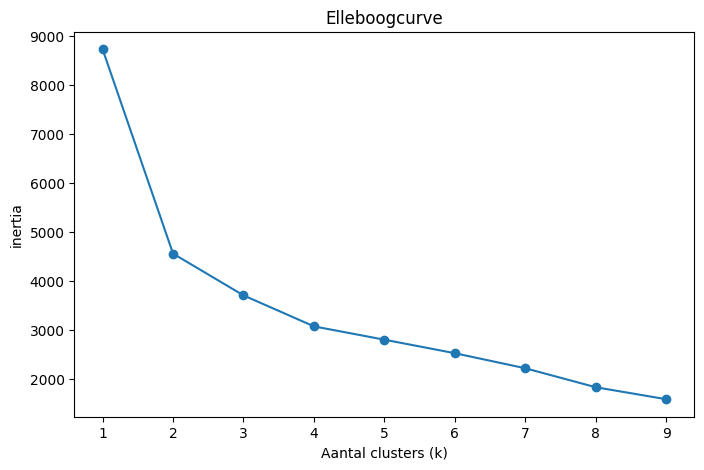

In [312]:
inertias = []
k_values = range(1, 10)

for k in k_values:
    kmean = KMeans(n_clusters=k, random_state=1)
    kmean.fit(df_2d[values2_d])
    inertias.append(kmean.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, inertias, marker='o')
plt.xlabel("Aantal clusters (k)")
plt.ylabel("inertia")
plt.title("Elleboogcurve")
plt.show

In [313]:
# features = ['SalePrice', 'Gr Liv Area']
# cat_features = []
# clusters = 3

In [314]:
def clustering_metrics_from_existing(df_2d, kmeans, kmeans_centra=None):
    import numpy as np
    import pandas as pd
    from sklearn.metrics.pairwise import euclidean_distances
    from sklearn.metrics import silhouette_score

    # data matrix and labels (from your objects)
    X = df_2d[values2_d].values
    labels = np.asarray(kmeans.labels_)

    # cluster centers
    if kmeans_centra is None:
        centers = np.asarray(kmeans.cluster_centers_)
    else:
        centers = np.asarray(kmeans_centra)  # accepts DataFrame or ndarray

    # intercluster distances
    intercluster_matrix = euclidean_distances(centers, centers)
    iu = np.triu_indices_from(intercluster_matrix, k=1)
    mean_intercluster = float(intercluster_matrix[iu].mean()) if iu[0].size > 0 else 0.0

    # intracluster distances (mean distance to center) per cluster
    intracluster_per_cluster = {}
    for i in range(centers.shape[0]):
        members = X[labels == i]
        if members.size == 0:
            intracluster_per_cluster[i] = float('nan')
        else:
            dists = np.linalg.norm(members - centers[i], axis=1)
            intracluster_per_cluster[i] = float(dists.mean())
    mean_intracluster = float(np.nanmean(list(intracluster_per_cluster.values())))

    # silhouette (requires >=2 clusters and enough samples)
    unique_labels = np.unique(labels)
    if unique_labels.size > 1 and X.shape[0] > unique_labels.size:
        sil = float(silhouette_score(X, labels))
    else:
        sil = float('nan')

    inter_df = pd.DataFrame(
        intercluster_matrix,
        index=[f'Cluster {i}' for i in range(centers.shape[0])],
        columns=[f'Cluster {i}' for i in range(centers.shape[0])]
    )

    return {
        "intercluster_matrix": inter_df,
        "mean_intercluster_distance": mean_intercluster,
        "intracluster_per_cluster": intracluster_per_cluster,
        "mean_intracluster_distance": mean_intracluster,
        "silhouette_score": sil
    }

# Usage with your variables:
metrics = clustering_metrics_from_existing(df_2d, kmean, kmeans_centra)
print(values2_d)
print(metrics['intercluster_matrix'])
print("Mean intercluster distance:", metrics['mean_intercluster_distance'])
print("Mean intracluster distance:", metrics['mean_intracluster_distance'])
print("Intracluster per cluster:", metrics['intracluster_per_cluster'])
print("Silhouette score:", metrics['silhouette_score'])

['Full Bath', 'Overall Qual', 'Bedroom AbvGr']
           Cluster 0  Cluster 1  Cluster 2  Cluster 3
Cluster 0   0.000000   1.703540   1.434589   3.371041
Cluster 1   1.703540   0.000000   2.294783   1.742666
Cluster 2   1.434589   2.294783   0.000000   3.754932
Cluster 3   3.371041   1.742666   3.754932   0.000000
Mean intercluster distance: 2.3835918886126453
Mean intracluster distance: 1.0254437193884336
Intracluster per cluster: {0: 0.6028287531832348, 1: 0.6288732605483144, 2: 1.460791651991936, 3: 1.4092812118302491}
Silhouette score: 0.4795687562087766


In [315]:
# aantal_clusters = 6
# kmeans = KMeans(n_clusters=aantal_clusters, random_state=1)
# kmeans.fit_predict(df)

# kmeans_centra = pd.DataFrame(kmeans.cluster_centers_, columns = df.columns)
# kmeans_centra.index.name = 'Cluster'

# afstanden_tot_centra = pd.DataFrame(euclidean_distances(df, kmeans_centra), index = df.index)

# for cluster_nummer in range(aantal_clusters):
#     afstanden_tot_centra = afstanden_tot_centra.rename(columns = {cluster_nummer : f'Afstand tot cluster_{cluster_nummer}'})

# df = pd.concat([df, afstanden_tot_centra], axis = 1)

# df['Cluster'] = df.iloc[:, -6].idxmin(axis=1)

# intercluster_matrix = pd.DataFrame(
#     euclidean_distances(kmeans_centra, kmeans_centra),
#     index=[f'Cluster {i}' for i in kmeans_centra.index],
#     columns=[f'Cluster {i}' for i in kmeans_centra.index]
# )

# print(intercluster_matrix)
